<a href="https://colab.research.google.com/github/frvalov3/SQLInjection/blob/main/BERT_LSTM_VER_2nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA PREPROCESSING

In [ ]:
import pandas as pd
from transformers import BertTokenizer
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
# Kết nối Google Drive để tải dữ liệu
from google.colab import drive
drive.mount('/content/drive')

# Đọc dữ liệu
data_link = '/content/drive/MyDrive/SQLI DataSet/Data/Test_dataset.csv'
data = pd.read_csv(data_link)

Mounted at /content/drive


In [ ]:
print(len(data))
print(data.head())

30919
                                               Query  Label
0                  " or pg_sleep  (  __TIME__  )  --      1
1  create user name identified by pass123 tempora...      1
2   AND 1  =  utl_inaddr.get_host_address   (    ...      1
3   select * from users where id  =  '1' or @ @1 ...      1
4   select * from users where id  =  1 or 1#"  ( ...      1


     NumQueries
0             1
1          6431
2           767
3           509
4           901
..          ...
95           22
96            9
97           16
98            1
216           1

[98 rows x 1 columns]


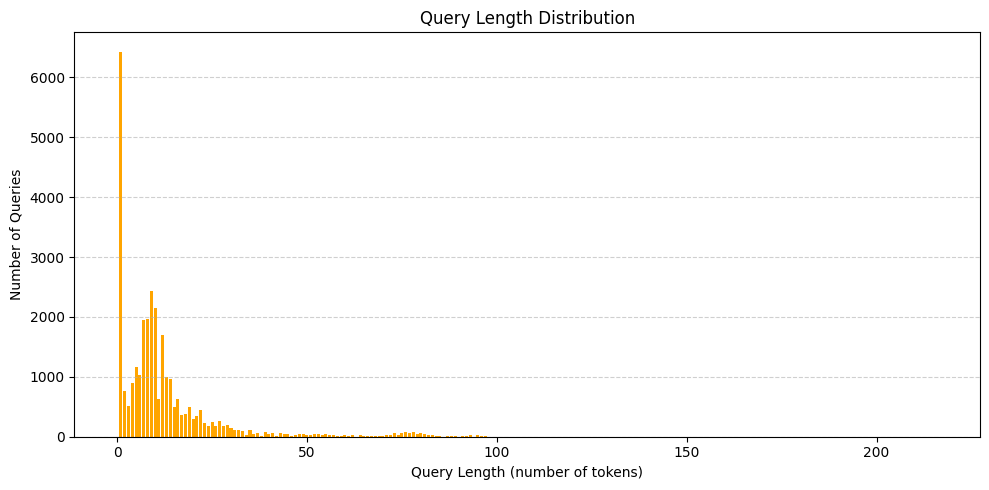

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Hàm đếm số lượng token (từ) trong mỗi câu query
def count_tokens(query):
    return len(query.split())

# Áp dụng hàm lên cột Query
data['TokenCount'] = data['Query'].apply(count_tokens)

# Thống kê số lượng câu theo độ dài
length_counts = Counter(data['TokenCount'])

# Chuyển thành DataFrame để xem
length_df = pd.DataFrame.from_dict(length_counts, orient='index', columns=['NumQueries'])
length_df = length_df.sort_index()

# Hiển thị bảng kết quả
print(length_df)

# Plot lại biểu đồ nếu muốn
plt.figure(figsize=(10,5))
plt.bar(length_df.index, length_df['NumQueries'], color='orange')
plt.title("Query Length Distribution")
plt.xlabel("Query Length (number of tokens)")
plt.ylabel("Number of Queries")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Tiền xử lý dữ liệu: giả định dữ liệu có cột 'Sentence' và 'Label'
import re

# Hàm để xử lý label
def clean_label(label):
    return 1 if label == "1" or label == 1 else 0

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Tạo danh sách stopwords tùy chỉnh với chữ in hoa
standard_stop_words = set(word.upper() for word in stopwords.words('english'))

# Định nghĩa các từ khóa SQL cần giữ lại (chữ in hoa)
sql_keywords = {
    'SELECT', 'FROM', 'WHERE', 'AND', 'OR', 'NOT', 'UNION', 'JOIN', 'INSERT',
    'UPDATE', 'DELETE', 'DROP', 'CREATE', 'ALTER', 'TABLE', 'INTO', 'VALUES',
    'SET', 'GROUP', 'BY', 'ORDER', 'HAVING', 'DISTINCT', 'LIMIT', 'OFFSET',
    'LIKE', 'IN', 'EXISTS', 'BETWEEN', 'NULL', 'IS', 'CASE', 'WHEN', 'THEN',
    'ELSE', 'END', 'AS'
}

# Tạo danh sách stopwords tùy chỉnh bằng cách loại bỏ các từ khóa SQL
custom_stop_words = standard_stop_words - sql_keywords

def clean_text(query):
    # Loại bỏ các ký tự không mong muốn nhưng giữ lại các ký tự đặc biệt của SQL
    # Bao gồm: chữ cái, chữ số, khoảng trắng, và các ký tự đặc biệt quan trọng trong SQL
    query = re.sub(r"[^\w\s\'\"=\>\<\(\);/\-\*]+", '', query)
    # Chuyển thành chữ in hoa
    query = query.upper()
    # Tách thành các từ
    words = query.split()
    # Loại bỏ stopwords sử dụng danh sách tùy chỉnh
    filtered_words = [word for word in words if word not in custom_stop_words]
    # Ghép lại thành câu truy vấn đã làm sạch
    cleaned_query = ' '.join(filtered_words)
    return cleaned_query


# Áp dụng hàm làm sạch cho cột dữ liệu văn bản
data['Query'] = data['Query'].apply(clean_text)

# Làm sạch dữ liệu
data = data[['Query', 'Label']].dropna(subset=['Query', 'Label'])
data['Label'] = data['Label'].apply(clean_label).astype(int)


sentences = data['Query'].tolist()
labels = data['Label'].tolist()

# Chia dữ liệu thành tập huấn luyện, xác thực và kiểm tra
train_sentences, temp_sentences, train_labels, temp_labels = train_test_split(
    sentences, labels, test_size=0.2, random_state=42)
val_sentences, test_sentences, val_labels, test_labels = train_test_split(
    temp_sentences, temp_labels, test_size=0.5, random_state=42)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# TRAINING MODEL

In [ ]:
# Khởi tạo tokenizer BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Định nghĩa lớp dữ liệu tùy chỉnh cho SQL Injection
class SQLInjectionDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_len):
        self.sentences = sentences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            sentence,
            max_length=self.max_len,
            add_special_tokens=True,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True,
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Thiết lập các biến số
MAX_LEN = 128
BATCH_SIZE = 16

# Xây dựng dataloader
# train_data_loader = DataLoader(
#     SQLInjectionDataset(train_sentences, train_labels, tokenizer, MAX_LEN),
#     batch_size=BATCH_SIZE,
#     shuffle=True
# )

# val_data_loader = DataLoader(
#     SQLInjectionDataset(val_sentences, val_labels, tokenizer, MAX_LEN),
#     batch_size=BATCH_SIZE,
#     shuffle=False
# )

# test_data_loader = DataLoader(
#     SQLInjectionDataset(test_sentences, test_labels, tokenizer, MAX_LEN),
#     batch_size=BATCH_SIZE,
#     shuffle=False
# )

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


BERT_LSTM MODEL

In [ ]:
from transformers import BertModel
import torch.nn as nn

class BertLSTMModel(nn.Module):
    def __init__(self, n_classes):
        super(BertLSTMModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.lstm = nn.LSTM(768, 128, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(p=0.3)
        self.linear = nn.Linear(128*2, n_classes)

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output, _ = self.lstm(bert_output.last_hidden_state)
        pooled_output = sequence_output[:, -1, :]
        output = self.dropout(pooled_output)
        return self.linear(output)

In [ ]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hàm huấn luyện một epoch
def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = loss_fn(outputs, labels)
        _, preds = torch.max(outputs, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    return correct_predictions.double() / len(data_loader.dataset), np.mean(losses)

# Hàm đánh giá mô hình
def eval_model(model, data_loader, loss_fn, device):
    model = model.eval()
    losses = []
    correct_predictions = 0
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = loss_fn(outputs, labels)
            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    # Tính các chỉ số Precision, Recall và F1 Score
    precision = precision_score(labels_all, preds_all, average='macro')
    recall = recall_score(labels_all, preds_all, average='macro')
    f1 = f1_score(labels_all, preds_all, average='macro')

    return correct_predictions.double() / len(data_loader.dataset), np.mean(losses), preds_all, labels_all, precision, recall, f1

# Hàm chuẩn bị dữ liệu
def get_data_loader(sentences, labels, tokenizer, max_len, batch_size,shuffle=True):
    dataset = SQLInjectionDataset(
        sentences=sentences,
        labels=labels,
        tokenizer=tokenizer,
        max_len=max_len
    )

    return DataLoader(dataset, batch_size=batch_size,shuffle=shuffle, num_workers=2)

# Thiết lập các biến số
MAX_LEN = 128
BATCH_SIZE = 16
N_CLASSES = 2
EPOCHS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Chuẩn bị dữ liệu và mô hình
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


from torch.optim.lr_scheduler import StepLR


# Xây dựng dataloader
train_data_loader = get_data_loader(train_sentences, train_labels, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=True)
val_data_loader = get_data_loader(val_sentences, val_labels, tokenizer, MAX_LEN, BATCH_SIZE,shuffle=False)
test_data_loader = get_data_loader(test_sentences, test_labels, tokenizer, MAX_LEN, BATCH_SIZE,shuffle=False)

model = BertLSTMModel(N_CLASSES)
model = model.to(DEVICE)

# Thiết lập các tiêu chí, optimizer và hàm loss
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss().to(DEVICE)

# Khởi tạo scheduler để giảm learning rate sau mỗi 3 epoch (ví dụ)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)



In [ ]:

# Huấn luyện và đánh giá mô hình
start_epoch = 0

# Kiểm tra nếu có checkpoint để tải lại
checkpoint_path = '/content/drive/MyDrive/SQLI DataSet/TrainedResult/bert_lstm_checkpoint.pth'
try:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Checkpoint loaded. Resuming from epoch {start_epoch + 1}.")
except FileNotFoundError:
    print("No checkpoint found. Starting training from scratch.")

# Huấn luyện từ epoch hiện tại
for epoch in range(start_epoch, EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)

    train_acc, train_loss = train_epoch(model, train_data_loader, loss_fn, optimizer, DEVICE)
    print(f'Train loss {train_loss} accuracy {train_acc}')

    val_acc, val_loss, preds, labels, precision, recall, f1 = eval_model(model, val_data_loader, loss_fn, DEVICE)
    scheduler.step()
    print(f'Val loss {val_loss} accuracy {val_acc}')
    print(f'Precision: {precision}, Recall: {recall}, F1: {f1}')
    print()

    # Lưu checkpoint sau mỗi epoch
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': train_loss
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch + 1}")

# Đánh giá mô hình trên tập kiểm tra
test_acc, test_loss, test_preds, test_labels, test_precision, test_recall, test_f1 = eval_model(model, test_data_loader, loss_fn, DEVICE)
print(f'Test Accuracy: {test_acc}, Test Loss: {test_loss}')
print(f'Test Precision: {test_precision}, Test Recall: {test_recall}, Test F1: {test_f1}')

No checkpoint found. Starting training from scratch.
Epoch 1/5
----------


<ipython-input-16-e08d7f4a2cc5>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Train loss 0.02624930877251765 accuracy 0.9937740044471397
Val loss 0.007078862987871561 accuracy 0.9977360931435965
Precision: 0.9980284701361262, Recall: 0.9971013350921463, F1: 0.9975616611662096

Checkpoint saved at epoch 1
Epoch 2/5
----------
Train loss 0.0070439146880840854 accuracy 0.99805942995755
Val loss 0.009146196661023759 accuracy 0.9974126778783959
Precision: 0.9979643765903308, Recall: 0.9964757709251102, F1: 0.9972117655917265

Checkpoint saved at epoch 2
Epoch 3/5
----------
Train loss 0.005586828110140343 accuracy 0.9987467151809177
Val loss 0.007318190215113477 accuracy 0.998706338939198
Precision: 0.9987929969493775, Recall: 0.99842292099523, F1: 0.998607440555006

Checkpoint saved at epoch 3
Epoch 4/5
----------
Train loss 0.0017313001258381585 accuracy 0.9997574287446938
Val loss 0.007983932427095235 accuracy 0.998706338939198
Precision: 0.9987929969493775, Recall: 0.99842292099523, F1: 0.998607440555006

Checkpoint saved at epoch 4
Epoch 5/5
----------
Train los

# MODEL SAU HUẤN LUYỆN ĐƯỢC LƯU THEO CHECKPOINT PATH

> checkpoint_path = '/content/drive/MyDrive/SQLI DataSet/TrainedResult/bert_lstm_checkpoint.pth'



# HUẤN LUYỆN THÊM TRƯỜNG HỢP METRIC CHƯA ĐÚNG MONG MUỐN

In [ ]:

# Tạo mô hình và optimizer mới (với cùng kiến trúc)
model = BertLSTMModel(N_CLASSES)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# Tải checkpoint đã lưu
checkpoint_path = '/content/drive/MyDrive/SQLI DataSet/TrainedResult/bert_lstm_checkpoint.pth'

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# Khôi phục trạng thái của mô hình và optimizer từ checkpoint
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']

# Chuyển mô hình sang thiết bị tính toán (CPU hoặc GPU)
model = model.to(DEVICE)

# Huấn luyện thêm từ epoch đã dừng lại
num_new_epochs = 5  #  cần huấn luyện thêm 5 epochs
for epoch in range(start_epoch, start_epoch + num_new_epochs):
    print(f'Epoch {epoch + 1}/{start_epoch + num_new_epochs}')
    print('-' * 10)

    train_acc, train_loss = train_epoch(model, train_data_loader, loss_fn, optimizer, DEVICE)
    print(f'Train loss {train_loss} accuracy {train_acc}')

    val_acc, val_loss, preds, labels, precision, recall, f1 = eval_model(model, val_data_loader, loss_fn, DEVICE)
    print(f'Val loss {val_loss} accuracy {val_acc}')
    print(f'Precision: {precision}, Recall: {recall}, F1: {f1}')
    print()

    # Lưu checkpoint sau mỗi epoch mới
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch + 1}")

In [ ]:
# Lưu mô hình mới với tên khác để kiểm tra hiệu suất
new_model_save_path = '/content/drive/MyDrive/SQLI DataSet/TrainedResult/bert_lstm_model_state_v2.pth'
torch.save(model.state_dict(), new_model_save_path)
print(f"New model saved to {new_model_save_path}")

# KIỂM TRA ĐÁNH GIÁ MODEL SAU HUẤN LUYỆN

In [ ]:

MAX_LEN = 128

N_CLASSES = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
import torch

# Đường dẫn tới checkpoint đã lưu
checkpoint_path = '/content/drive/MyDrive/SQLI DataSet/TrainedResult/bert_lstm_checkpoint.pth'

# Tạo lại mô hình với cùng kiến trúc
model = BertLSTMModel(n_classes=2)

# Tải checkpoint
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# Khôi phục trạng thái mô hình từ checkpoint
model.load_state_dict(checkpoint['model_state_dict'])

# Chuyển mô hình sang thiết bị tính toán (CPU hoặc GPU)
model = model.to(DEVICE)

# Đặt mô hình ở chế độ đánh giá để không tính gradient
model.eval()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

<ipython-input-8-9303ddb254c7>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


BertLSTMModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

In [ ]:

import nltk
nltk.download('stopwords')

import re
from nltk.corpus import stopwords

# Tạo danh sách stopwords tùy chỉnh với chữ in hoa
standard_stop_words = set(word.upper() for word in stopwords.words('english'))

# Định nghĩa các từ khóa SQL cần giữ lại (chữ in hoa)
sql_keywords = {
    'SELECT', 'FROM', 'WHERE', 'AND', 'OR', 'NOT', 'UNION', 'JOIN', 'INSERT',
    'UPDATE', 'DELETE', 'DROP', 'CREATE', 'ALTER', 'TABLE', 'INTO', 'VALUES',
    'SET', 'GROUP', 'BY', 'ORDER', 'HAVING', 'DISTINCT', 'LIMIT', 'OFFSET',
    'LIKE', 'IN', 'EXISTS', 'BETWEEN', 'NULL', 'IS', 'CASE', 'WHEN', 'THEN',
    'ELSE', 'END', 'AS'
}

# Tạo danh sách stopwords tùy chỉnh bằng cách loại bỏ các từ khóa SQL
custom_stop_words = standard_stop_words - sql_keywords

def clean_text(query):
    # Loại bỏ các ký tự không mong muốn nhưng giữ lại các ký tự đặc biệt của SQL
    # Bao gồm: chữ cái, chữ số, khoảng trắng, và các ký tự đặc biệt quan trọng trong SQL
    query = re.sub(r"[^\w\s\'\"=\>\<\(\);/\-\*]+", '', query)
    # Chuyển thành chữ in hoa
    query = query.upper()
    # Tách thành các từ
    words = query.split()
    # Loại bỏ stopwords sử dụng danh sách tùy chỉnh
    filtered_words = [word for word in words if word not in custom_stop_words]
    # Ghép lại thành câu truy vấn đã làm sạch
    cleaned_query = ' '.join(filtered_words)
    return cleaned_query

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Tokenizer cho câu truy vấn
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def predict_single_query(model, query, tokenizer, max_len=128):
    model.eval()  # Đặt mô hình ở chế độ đánh giá để không tính gradient

    # Sử dụng hàm clean_text để tiền xử lý câu truy vấn
    cleaned_query = clean_text(query)
    print(f"Clean Query: {cleaned_query}")

    # Tiền xử lý câu truy vấn với tokenizer
    encoding = tokenizer.encode_plus(
        cleaned_query,
        max_length=max_len,
        add_special_tokens=True,
        return_token_type_ids=False,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt',
        truncation=True,
    )

    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    # Dự đoán nhãn cho câu truy vấn
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    return predicted_class, confidence


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
normal_queries = [
    "SELECT name, email FROM users WHERE id = 1 UNION select name, id from user_asset where id = 1",
    "SELECT product_name, price FROM products WHERE category = 'Electronics'",
    "SELECT name FROM company WHERE id = 1 AND is_active = 1",
    "SELECT * FROM products WHERE id = 1 AND price > 100",
    "SELECT name FROM company WHERE id = 1 AND active = 2",
    "SELECT * FROM products WHERE id = 2 AND stock > 0",
    "SELECT name FROM users WHERE id = 1",
    "SELECT * FROM products WHERE id = 2",
    "Anh trai say hi",
]

sqli_queries = [
    "SELECT * FROM users WHERE user_name = 'Uname' AND password ='' OR 1 = 1 "
    "SELECT name, email FROM users WHERE id = 1 UNION SELECT username, password FROM admins--",
    "SELECT * FROM products WHERE id = 1 UNION SELECT credit_card_number, cvv FROM payment_info--",
    "SELECT name FROM users WHERE id = 1 AND 1=CONVERT(int, (SELECT @@version))--",
    "SELECT * FROM products WHERE id = 1 AND 1=CONVERT(int, (SELECT TOP 1 table_name FROM information_schema.tables))--",
    "SELECT name FROM users WHERE id = 1 AND 1=1--",
    "SELECT name FROM users WHERE id = '' OR 1=1",
    "SELECT * FROM products WHERE id = 2 AND 1=0--",
    "SELECT name FROM users WHERE id = 1; WAITFOR DELAY '00:00:05'--",
    "SELECT * FROM products WHERE id = 2 AND IF(1=1, SLEEP(5), 0)--",
    " OR 1=1"
]

# Combine normal and sqli queries into a single dataset
all_queries = normal_queries + sqli_queries

In [ ]:
# Thực hiện dự đoán và in kết quả
for query in all_queries:

    predicted_class, confidence = predict_single_query(model, query, tokenizer)

    # In kết quả dự đoán
    label_map = {0: "Normal", 1: "SQL Injection"}
    print(f"Predicted Class: {label_map[predicted_class]}, Confidence: {confidence:.4f}")
    print(f"Query: {query}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 80)

Clean Query: SELECT NAME EMAIL FROM USERS WHERE ID = 1 UNION SELECT NAME ID FROM USER_ASSET WHERE ID = 1
Predicted Class: SQL Injection, Confidence: 0.9908
Query: SELECT name, email FROM users WHERE id = 1 UNION select name, id from user_asset where id = 1
Confidence: 0.9908
--------------------------------------------------------------------------------
Clean Query: SELECT PRODUCT_NAME PRICE FROM PRODUCTS WHERE CATEGORY = 'ELECTRONICS'
Predicted Class: Normal, Confidence: 0.9998
Query: SELECT product_name, price FROM products WHERE category = 'Electronics'
Confidence: 0.9998
--------------------------------------------------------------------------------
Clean Query: SELECT NAME FROM COMPANY WHERE ID = 1 AND IS_ACTIVE = 1
Predicted Class: Normal, Confidence: 0.9998
Query: SELECT name FROM company WHERE id = 1 AND is_active = 1
Confidence: 0.9998
--------------------------------------------------------------------------------
Clean Query: SELECT * FROM PRODUCTS WHERE ID = 1 AND PRICE >

RANDOM DATA

In [ ]:
import random

# Template for generating different types of SQL injection queries and normal queries
normal_templates = [
    "SELECT {} FROM {} WHERE {} = {}",
    "SELECT {} FROM {} WHERE {} = '{}' AND {} = {}",
    "SELECT * FROM {} WHERE {} = {}",
    "SELECT {}, {} FROM {} WHERE {} > {}",
    "SELECT {} FROM {} WHERE {} LIKE '{}'"
]

sqli_union_templates = [
    "SELECT {} FROM {} WHERE {} = {} UNION SELECT {}, {} FROM {}--",
    "SELECT * FROM {} WHERE {} = {} UNION SELECT {}, {} FROM {}--",
    "SELECT {} FROM {} WHERE {} = {} UNION SELECT username, password FROM {}--"
]

sqli_error_templates = [
    "SELECT {} FROM {} WHERE {} = {} AND 1=CONVERT(int, (SELECT @@version))--",
    "SELECT * FROM {} WHERE {} = {} AND 1=CONVERT(int, (SELECT TOP 1 table_name FROM information_schema.tables))--",
    "SELECT {} FROM {} WHERE {} = {} AND 1=CONVERT(int, (SELECT TOP 1 {}, {} FROM {}))--"
]

sqli_boolean_templates = [
    "SELECT {} FROM {} WHERE {} = {} AND 1=1--",
    "SELECT {} FROM {} WHERE {} = {} AND 1=0--",
    "SELECT * FROM {} WHERE {} = {} AND {}={}--"
]

sqli_time_templates = [
    "SELECT {} FROM {} WHERE {} = {}; WAITFOR DELAY '00:00:05'--",
    "SELECT * FROM {} WHERE {} = {} AND IF(1=1, SLEEP(5), 0)--",
    "SELECT {} FROM {} WHERE {} = {}; WAITFOR DELAY '00:00:10'--"
]

# Lists of random columns, tables, and conditions to fill the templates
columns = ['name', 'email', 'price', 'stock', 'username', 'password', 'category', 'product_name', 'id']
tables = ['users', 'admins', 'products', 'orders', 'payment_info', 'user_data', 'inventory']
conditions = ['id', 'category', 'stock', 'is_active', 'price', 'email']

# Generate 5 normal queries
# Tạo các truy vấn bình thường
normal_queries_generated = []

for _ in range(10):
    # Chọn một template ngẫu nhiên
    template = random.choice(normal_templates)

    # Sử dụng các điều kiện khác nhau tùy thuộc vào số lượng `{}` trong template
    if template.count("{}") == 4:  # Ví dụ "SELECT {} FROM {} WHERE {} = {}"
        query = template.format(
            random.choice(columns),
            random.choice(tables),
            random.choice(conditions),
            random.randint(1, 100)
        )
    elif template.count("{}") == 6:  # Ví dụ "SELECT {}, {} FROM {} WHERE {} > {} AND {} < {}"
        query = template.format(
            random.choice(columns),
            random.choice(columns),
            random.choice(tables),
            random.choice(conditions),
            random.randint(1, 100),
            random.choice(conditions),
            random.randint(1, 100)
        )
    elif template.count("{}") == 3:  # Ví dụ "SELECT * FROM {} WHERE {} = {}"
        query = template.format(
            random.choice(tables),
            random.choice(conditions),
            random.randint(1, 100)
        )
    # Added a new case to handle templates with 4 placeholders

    normal_queries_generated.append(query)

# Generate 20 SQL injection queries (5 from each type)
sqli_queries_generated = []

# UNION based
sqli_queries_generated += [random.choice(sqli_union_templates).format(
    random.choice(columns), random.choice(tables), random.choice(conditions), random.randint(1, 100),
    random.choice(columns), random.choice(columns), random.choice(tables)) for _ in range(8)]

# Error-based
sqli_queries_generated += [random.choice(sqli_error_templates).format(
    random.choice(columns), random.choice(tables), random.choice(conditions), random.randint(1, 100),
    random.choice(columns), random.choice(columns), random.choice(tables)) for _ in range(8)]

# Boolean-based
sqli_queries_generated += [random.choice(sqli_boolean_templates).format(
    random.choice(columns), random.choice(tables), random.choice(conditions), random.randint(1, 100),
    random.randint(1, 100)) for _ in range(8)]

# Time-based
sqli_queries_generated += [random.choice(sqli_time_templates).format(
    random.choice(columns), random.choice(tables), random.choice(conditions), random.randint(1, 100)) for _ in range(8)]

# Combine all generated queries
all_generated_queries = normal_queries_generated + sqli_queries_generated


In [ ]:
# Thực hiện dự đoán và in kết quả
for query in all_generated_queries:

    predicted_class, confidence = predict_single_query(model, query, tokenizer)

    # In kết quả dự đoán
    label_map = {0: "Normal", 1: "SQL Injection"}
    print(f"Predicted Class: {label_map[predicted_class]}, Confidence: {confidence:.4f}")
    print(f"Query: {query}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 80)

Clean Query: OR 1=1
Predicted Class: SQL Injection, Confidence: 0.9998
Query:  OR 1=1
Confidence: 0.9998
--------------------------------------------------------------------------------
Clean Query: SELECT CATEGORY FROM ADMINS WHERE STOCK LIKE '25'
Predicted Class: Normal, Confidence: 0.9998
Query: SELECT category FROM admins WHERE stock LIKE '25'
Confidence: 0.9998
--------------------------------------------------------------------------------
Clean Query: SELECT EMAIL FROM EMAIL WHERE PRODUCTS = 'STOCK' AND 58 = IS_ACTIVE
Predicted Class: Normal, Confidence: 0.9998
Query: SELECT email FROM email WHERE products = 'stock' AND 58 = is_active
Confidence: 0.9998
--------------------------------------------------------------------------------
Clean Query: SELECT * FROM INVENTORY WHERE ID = 50
Predicted Class: Normal, Confidence: 0.9998
Query: SELECT * FROM inventory WHERE id = 50
Confidence: 0.9998
--------------------------------------------------------------------------------
Clean Quer

# FINETUNE MODEL nếu kết quả dự đoán chưa như mong muốn







In [ ]:
# Kết nối Google Drive để tải dữ liệu
from google.colab import drive
!pip install transformers
!pip install nltk
!pip install chardet

# Import các thư viện
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertModel
import pandas as pd
import re
import nltk
import chardet

drive.mount('/content/drive')

# Đọc dữ liệu
data_link = '/content/drive/MyDrive/SQLI DataSet/Data/Test_dataset.csv'
finetune_data = pd.read_csv(data_link)

In [ ]:

# Phát hiện encoding của file
with open('/content/drive/MyDrive/SQLI DataSet/Data/Test_dataset.csv', 'rb') as rawdata:
    result = chardet.detect(rawdata.read(100000))

# Đọc file với encoding đã phát hiện
finetune_data = pd.read_csv('/content/drive/MyDrive/SQLI DataSet/Data/Test_dataset.csv', encoding=result['encoding'])
print(finetune_data.columns)

# Loại bỏ các dòng có giá trị NaN trong cột 'Query'
finetune_data = finetune_data.dropna(subset=['Query'])

# Loại bỏ các dòng có giá trị chuỗi rỗng (sau khi loại bỏ khoảng trắng)
finetune_data = finetune_data[finetune_data['Query'].str.strip() != '']

# Lấy danh sách các câu query và nhãn
train_sentences = finetune_data['Query'].tolist()
train_labels = finetune_data['Label'].tolist()

# In số lượng mẫu sau khi làm sạch
print(f"Số lượng mẫu sau khi làm sạch: {len(train_sentences)}")

In [ ]:
# Hàm chuẩn bị dữ liệu (cập nhật để sử dụng clean_text)
def get_data_loader(sentences, labels, tokenizer, max_len, batch_size):
    # Tiền xử lý tất cả các câu truy vấn bằng hàm clean_text
    cleaned_sentences = [clean_text(sentence) for sentence in sentences]

    dataset = SQLInjectionDataset(
        sentences=cleaned_sentences,
        labels=labels,
        tokenizer=tokenizer,
        max_len=max_len
    )

    return DataLoader(dataset, batch_size=batch_size, num_workers=2)

# Chuẩn bị dữ liệu và mô hình
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Xây dựng dataloader với dữ liệu đã được tiền xử lý
train_data_loader = get_data_loader(train_sentences, train_labels, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = get_data_loader(val_sentences, val_labels, tokenizer, MAX_LEN, BATCH_SIZE)

# Tiếp tục huấn luyện (fine-tune)
num_new_epochs = 3  # Số epoch cần fine-tune thêm
for epoch in range(start_epoch, start_epoch + num_new_epochs):
    print(f'Epoch {epoch + 1}/{start_epoch + num_new_epochs}')
    print('-' * 10)

    train_acc, train_loss = train_epoch(model, train_data_loader, loss_fn, optimizer, DEVICE)
    print(f'Train loss {train_loss} accuracy {train_acc}')

    val_acc, val_loss, preds, labels, precision, recall, f1 = eval_model(model, val_data_loader, loss_fn, DEVICE)
    print(f'Val loss {val_loss} accuracy {val_acc}')
    print(f'Precision: {precision}, Recall: {recall}, F1: {f1}')
    print()

    # Lưu checkpoint sau mỗi epoch mới
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch + 1}")

30918


# KIỂM TRA DỰ ĐOÁN CỦA MODEL SAU KHI FINETUNE

# Kiểm tra model metric với tập dữ liệu mới Test_dataset.csv/sqli.csv